# The analysis scripts for Bulk system of fcc Si

## Free energy versus lattice constant

In the file `SUMMARY.fcc`

+ The 1st column: lattice parameter (in Å units)
+ The 2nd column: unit number (always 1 in this case)
+ The 3rd column: free energy (in eV units)
+ The 4th column: initial energy (in eV units)
+ The 5th column: energy change (difference between initial and current energy, in eV units)

In [1]:
# Extract the data for the free energy versus lattice constant
with open('Bulk_fcc_Si/SUMMARY.fcc', 'r') as f:
    lines = f.readlines()

# Initialize the lists for lattice constant and free energy
lattice_list, free_energy_list, initial_energy_list, difference_energy_list = [], [], [], []

# Loop through each line in the file
for line in lines:
    # Check if the line contains the required information
    if 'F=' in line and 'E0=' in line and 'd E =' in line:
        # Extract the lattice constant
        lattice = float(line.split()[0])
        lattice_list.append(lattice)
        # Extract the free energy
        free_energy = float(line.split()[3])
        free_energy_list.append(free_energy)
        # Extract the initial energy
        initial_energy = float(line.split()[5])
        initial_energy_list.append(initial_energy)
        # Extract the energy change
        difference_energy = float(line.split()[8].replace('=',''))
        difference_energy_list.append(difference_energy)

# Print the results
print('Lattice constant:', lattice_list)
print('Free energy:', free_energy_list)
print('Initial energy:', initial_energy_list)
print('Energy change:', difference_energy_list)


Lattice constant: [3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]
Free energy: [-2.906493, -3.5930289, -4.0836003, -4.4257374, -4.6615601, -4.7980994, -4.8646179, -4.8774699, -4.8487888, -4.7853071, -4.6937274, -4.5831559, -4.4613553, -4.3282512, -4.1873138, -4.0409916, -3.8893874, -3.734202, -3.5785211]
Initial energy: [-2.9058916, -3.59263, -4.0834702, -4.4234652, -4.6601305, -4.7960429, -4.8631198, -4.875939, -4.8481543, -4.7845289, -4.6922855, -4.581223, -4.4593939, -4.3263727, -4.185868, -4.0400095, -3.8883256, -3.7328571, -3.5772953]
Energy change: [-0.00120277, -0.000797729, -0.000260163, -0.00454452, -0.00285925, -0.00411307, -0.00299633, -0.00306188, -0.00126897, -0.00155634, -0.00288389, -0.00386577, -0.00392283, -0.0037569, -0.00289174, -0.00196422, -0.00212347, -0.00268977, -0.00245159]


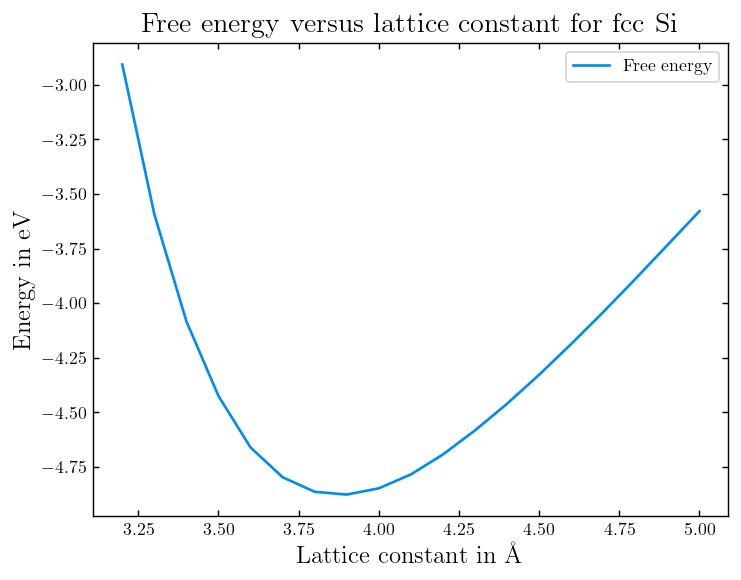

In [2]:
# Plot
import numpy as np
import matplotlib.pyplot as plt

# Set up the specified style parameters
plt.figure(dpi=128)
params = {"text.usetex": True, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

plt.title("Free energy versus lattice constant for fcc Si"); plt.xlabel(r"Lattice constant in Å"); plt.ylabel(r"Energy in eV")
plt.plot(lattice_list, free_energy_list, c="#008CF0", label="Free energy")
# plt.plot(lattice_list, initial_energy_list, c="#FA9600", label="Initial energy")
# plt.plot(lattice_list, difference_energy_list, c="#8C64F0", label="Energy change")

plt.legend(loc="best")


## Electronic density versus energy


In [3]:
# Import the necessary packages
import xml.etree.ElementTree as ET

# Analysis vasprun.xml file
tree = ET.parse('Bulk_fcc_Si_DOS/vasprun.xml')
root = tree.getroot()

# Extract Fermi energy
efermi = float(root.find(".//i[@name='efermi']").text)

# Extract Energies Total DOS Integrated DOS
energies_list, total_dos_list, integrated_dos_list = [], [], []

for r_element in root.findall(".//set[@comment='spin 1']/r"):
    values = list(map(float, r_element.text.split()))
    energies = values[0]
    energies_list.append(energies)
    total_dos = values[1]
    total_dos_list.append(total_dos)
    integrated_dos = values[2]
    integrated_dos_list.append(integrated_dos)

print("Fermi energy:", efermi)
print("Energies:", energies_list)
print("Total DOS:", total_dos_list)
print("Integrated DOS:", integrated_dos_list)

# print(efermi)
# print(len(energies_list), energies_list)
# print(len(total_dos_list), total_dos_list)
# print(len(integrated_dos_list), integrated_dos_list)


Fermi energy: 2.54964533
Energies: [-8.1339, -8.0176, -7.9013, -7.785, -7.6687, -7.5524, -7.4361, -7.3198, -7.2035, -7.0872, -6.9709, -6.8546, -6.7383, -6.622, -6.5057, -6.3894, -6.2731, -6.1568, -6.0405, -5.9242, -5.8079, -5.6916, -5.5753, -5.459, -5.3427, -5.2264, -5.1101, -4.9938, -4.8775, -4.7612, -4.6449, -4.5286, -4.4123, -4.296, -4.1797, -4.0634, -3.9471, -3.8308, -3.7145, -3.5982, -3.4819, -3.3657, -3.2494, -3.1331, -3.0168, -2.9005, -2.7842, -2.6679, -2.5516, -2.4353, -2.319, -2.2027, -2.0864, -1.9701, -1.8538, -1.7375, -1.6212, -1.5049, -1.3886, -1.2723, -1.156, -1.0397, -0.9234, -0.8071, -0.6908, -0.5745, -0.4582, -0.3419, -0.2256, -0.1093, 0.007, 0.1233, 0.2396, 0.3559, 0.4722, 0.5885, 0.7048, 0.8211, 0.9374, 1.0537, 1.17, 1.2863, 1.4026, 1.5189, 1.6352, 1.7515, 1.8678, 1.9841, 2.1004, 2.2167, 2.333, 2.4493, 2.5656, 2.6819, 2.7982, 2.9145, 3.0308, 3.1471, 3.2634, 3.3797, 3.496, 3.6123, 3.7286, 3.8449, 3.9612, 4.0775, 4.1938, 4.3101, 4.4264, 4.5427, 4.659, 4.7753, 4.8916, 5.

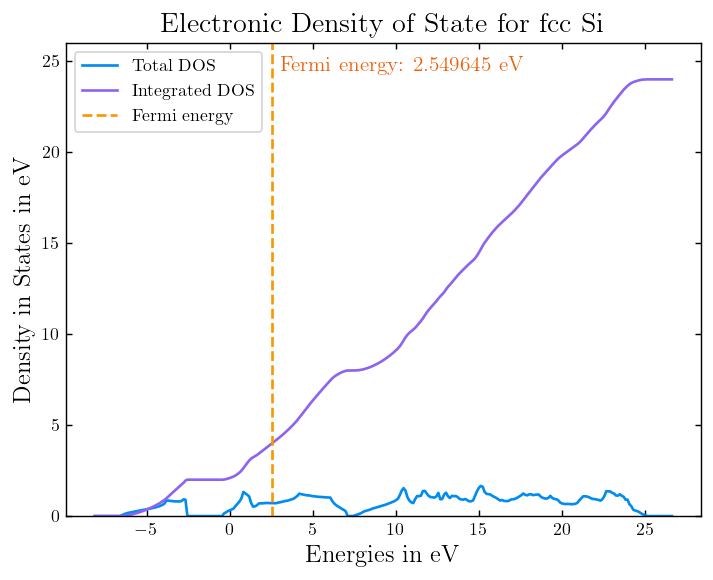

In [4]:
# Plot
import numpy as np
import matplotlib.pyplot as plt

# Set up the specified style parameters
plt.figure(dpi=128)
params = {"text.usetex": True, "font.family": "serif", "mathtext.fontset": "cm", "axes.titlesize": 16, "axes.labelsize": 14, "figure.facecolor": "w"}
plt.rcParams.update(params)
plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

plt.title("Electronic Density of State for fcc Si"); plt.xlabel(r"Energies in eV"); plt.ylabel(r"Density in States in eV")
plt.plot(energies_list[0:300], total_dos_list[0:300], c="#008CF0", label="Total DOS")
plt.plot(energies_list[0:300], integrated_dos_list[0:300], c="#8C64F0", label="Integrated DOS")

# Plot Fermi energy as a vertical line
plt.axvline(x=efermi, linestyle="--", color="#FA9600", label="Fermi energy")

# Add Fermi energy value to the plot
fermi_energy_text = f"Fermi energy: {efermi:.6f} eV"
plt.text(efermi+0.5, 24.5, fermi_energy_text, fontsize=12, color="#F05F0A", rotation=0)

plt.ylim(0,26)
plt.legend(loc="best")
plt.show()


## Bandstructure

The band structure is demonstrated with Energy (in eV) versus K-point distance (in Å).

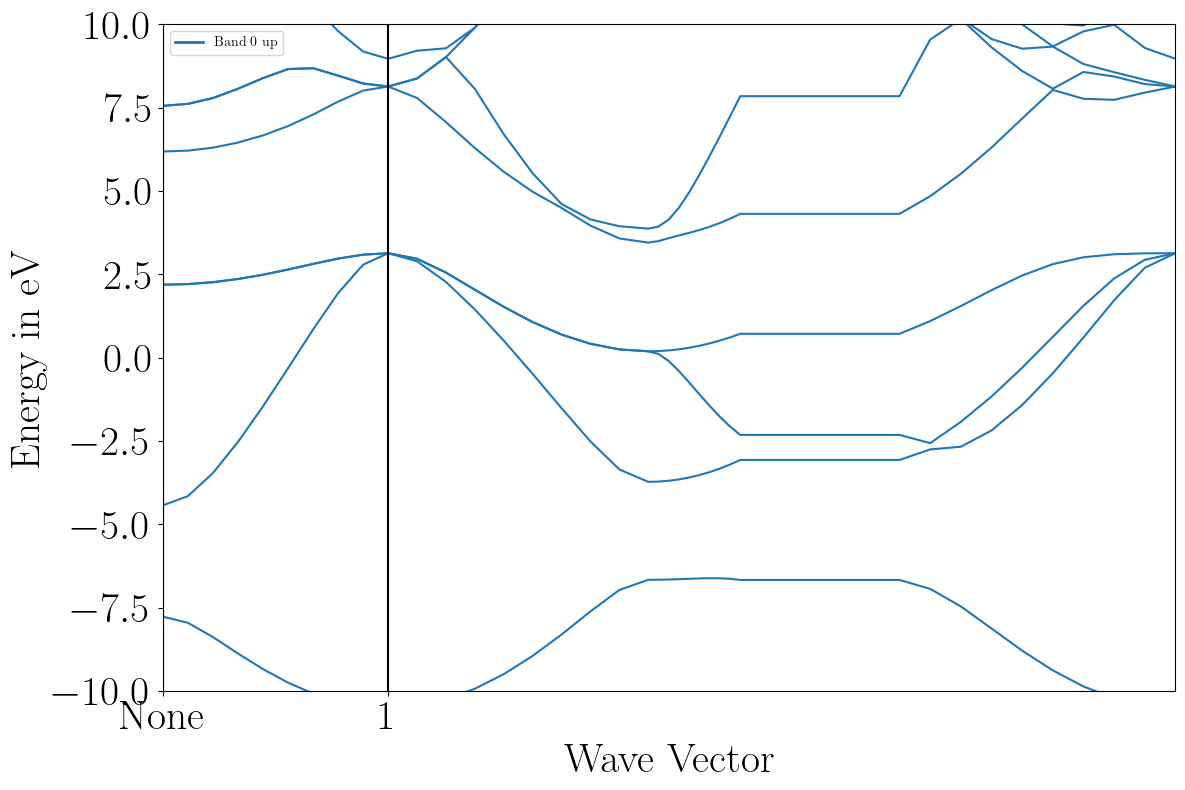

In [26]:
# from pymatgen.electronic_structure.plotter import BSPlotter
# from pymatgen.io.vasp import Vasprun

# # Extract the band structure data from the vasprun.xml file
# vasprun = Vasprun("Bulk_fcc_Si_bandstructure/vasprun.xml")
# band_structure = vasprun.get_band_structure()

# # Use pymatgen's BSPlotter tool to plot the band structure
# plotter = BSPlotter(band_structure)
# plotter.get_plot().show()

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.io.vasp import Vasprun
import matplotlib.pyplot as plt

# Extract the band structure data from the vasprun.xml file
vasprun = Vasprun("Bulk_fcc_Si_bandstructure/vasprun.xml")
band_structure = vasprun.get_band_structure()

# Use pymatgen's BSPlotter tool to plot the band structure
plotter = BSPlotter(band_structure)

# Plot the band structure
plt = plotter.get_plot()
plt.xlabel(r"Wave Vector")
plt.ylabel(r"Energy in eV")

plt.show()
